# Data Preprocessing and Modeling

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 0.0121 - val_loss: 0.0194
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0044 - val_loss: 0.0115
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0036 - val_loss: 0.0076
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0032 - val_loss: 0.0109
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0030 - val_loss: 0.0144
Epoch 8/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0030 - val_loss: 0.0186
Epoch 9/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0027 - val_loss: 0.0066
Epoch 10/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0030 - val_loss: 0.0203
Epoch 11/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0026 - val_loss: 0.0042
Epoch 12/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0

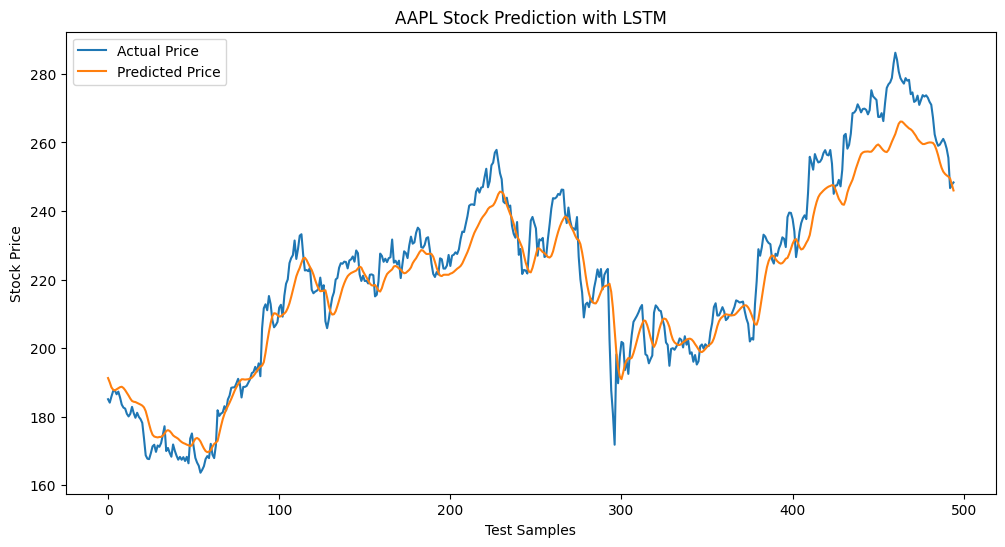

In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# Load data

df = pd.read_csv("./data/faang_stock_prices.csv")

# Sort data
df = df.sort_values(["Ticker", "Date"])


# Filter one company

company_df = df[df["Ticker"] == "AAPL"].copy()

# Sort by date
company_df = company_df.sort_values("Date")


# Select features

# Use multiple stock features
features = ["Open", "High", "Low", "Close"]

# Keep selected columns
data = company_df[features].values


# Create sequences

window_size = 20

X = []
y = []

for i in range(len(data) - window_size):

    # Previous 20 days
    x_window = data[i:i+window_size]

    # Next day's closing price
    y_value = data[i+window_size][3]

    # Store values
    X.append(x_window)
    y.append(y_value)


# Convert to arrays

X = np.array(X)
y = np.array(y)


# Train/test split

split_index = int(len(X) * 0.8)

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]


# Scale X values

x_scaler = MinMaxScaler()

# Reshape training data
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])

# Fit and transform training data
X_train_scaled = x_scaler.fit_transform(X_train_reshaped)

# Reshape back
X_train_scaled = X_train_scaled.reshape(X_train.shape)

# Reshape testing data
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])

# Transform testing data
X_test_scaled = x_scaler.transform(X_test_reshaped)

# Reshape back
X_test_scaled = X_test_scaled.reshape(X_test.shape)


# Scale y values

y_scaler = MinMaxScaler()

# Scale training targets
y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, 1)
)

# Scale testing targets
y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, 1)
)


# Build LSTM model

model = Sequential()

# First LSTM layer
model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(window_size, 4)
    )
)

# Dropout layer
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(32))

# Dropout layer
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))


# Compile model

model.compile(
    optimizer="adam",
    loss="mse"
)

# Show model structure
model.summary()


# Train model

history = model.fit(
    X_train_scaled,
    y_train_scaled,

    epochs=40,
    batch_size=32,

    validation_data=(
        X_test_scaled,
        y_test_scaled
    )
)


# Make predictions

predictions = model.predict(X_test_scaled)

# Convert predictions back to real prices
predictions = y_scaler.inverse_transform(predictions)

# Convert y_test back to real prices
y_test_actual = y_scaler.inverse_transform(
    y_test_scaled
)


# Plot results

plt.figure(figsize=(12,6))

# Actual stock prices
plt.plot(
    y_test_actual,
    label="Actual Price"
)

# Predicted stock prices
plt.plot(
    predictions,
    label="Predicted Price"
)

# Graph labels
plt.title("AAPL Stock Prediction with LSTM")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")

# Show legend
plt.legend()

# Display graph
plt.show()

In [3]:
# Print prediction ranges

print("\nPrediction Results:\n")

print(
    "Predicted min/max:",
    round(predictions.min(), 2),
    "/",
    round(predictions.max(), 2)
)

print(
    "Actual min/max:",
    round(y_test_actual.min(), 2),
    "/",
    round(y_test_actual.max(), 2)
)


Prediction Results:

Predicted min/max: 169.67 / 266.1
Actual min/max: 163.66 / 286.19
